# 01 — Black-Scholes-Merton: the analytical engine

The foundation of the library: closed-form pricing, **16 Greeks in a single pass**, and a
production implied-volatility solver (Halley's method, 2-4 iterations).

Under the risk-neutral measure $\mathbb{Q}$, the spot follows
$dS_t = (r - q)\,S_t\,dt + \sigma S_t\,dW_t^{\mathbb{Q}}$, and the European call/put prices are

$$C = S e^{-qT} N(d_1) - K e^{-rT} N(d_2), \qquad P = C - S e^{-qT} + K e^{-rT},$$

$$d_1 = \frac{\ln(S/K) + (r - q + \tfrac{1}{2}\sigma^2)\,T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}.$$

Everything shown here is cross-checked: textbook anchors (Hull), put-call parity to machine
precision, and a solver round-trip. The full test suite (977 tests) lives in `tests/`.

In [1]:
import sys
import time
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "exotic_option_pricer").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np

np.set_printoptions(precision=6, suppress=True)

from exotic_option_pricer.models import BlackScholesModel

bs = BlackScholesModel(sigma=0.20)
bs

BlackScholesModel(sigma=0.2)

## Pricing and put-call parity

Anchor: Hull's classic example (S=42, K=40, T=0.5, r=10%, $\sigma$=20%) — the call is worth
$\approx 4.76$ and the put $\approx 0.81$. Parity must hold to machine precision because the
put is *derived* from the call, not integrated separately.

In [2]:
S, K, T, r = 42.0, 40.0, 0.5, 0.10

c = bs.price(S, K, T, r, 'call')
p = bs.price(S, K, T, r, 'put')
parity_gap = abs((c - p) - (S - K * np.exp(-r * T)))

print(f"call = {c:.4f}   (Hull: 4.76)")
print(f"put  = {p:.4f}   (Hull: 0.81)")
print(f"|C - P - (S - K e^(-rT))| = {parity_gap:.2e}")

assert abs(c - 4.76) < 0.01 and abs(p - 0.81) < 0.01
assert parity_gap < 1e-12

# Vectorized over strikes: one call, one array
strikes = np.arange(30, 55, 5, dtype=float)
print("\nK:     ", strikes)
print("calls: ", bs.price(S, strikes, T, r, 'call'))
print("puts:  ", bs.price(S, strikes, T, r, 'put'))

call = 4.7594   (Hull: 4.76)
put  = 0.8086   (Hull: 0.81)
|C - P - (S - K e^(-rT))| = 1.78e-15

K:      [30. 35. 40. 45. 50.]
calls:  [13.467768  8.817807  4.759422  2.009147  0.658228]
puts:   [0.004651 0.110837 0.808599 2.814471 6.219699]


## Price decomposition: intrinsic vs time value

The gap between the option price and its intrinsic value is the *time value* — largest ATM,
where the exercise decision is most uncertain.

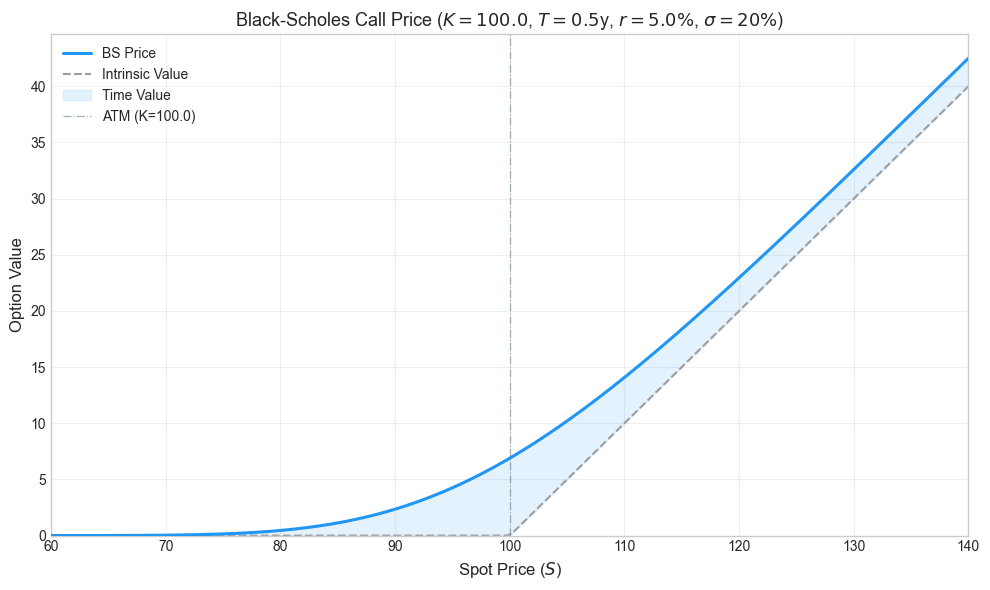

In [3]:
from exotic_option_pricer.utils.visualization import plot_bs_price_and_intrinsic

S_range = np.linspace(60, 140, 200)
fig, ax = plot_bs_price_and_intrinsic(bs, S_range, K=100.0, T=0.5, r=0.05)

## The Greeks: 16 sensitivities in one pass

`greeks()` returns first-order (delta, gamma, vega, theta, rho), second-order
(vanna, volga, charm, speed, zomma, color), dual (strike-space) Greeks and utilities —
computed analytically, no bumping, sharing the $d_1/d_2$ computation.

In [4]:
g = bs.greeks(100.0, 100.0, 1.0, 0.05, 'call')
for name, value in g.items():
    print(f"{name:>16}: {float(value):+.6f}")

           price: +10.450584
           delta: +0.636831
           gamma: +0.018762
            vega: +37.524035
           theta: -6.414028
             rho: +53.232482
           vanna: -0.281430
           volga: +9.850059
           charm: -0.065667
           speed: -0.000516
           zomma: -0.088885
           color: -0.010530
      dual_delta: -0.532325
      dual_gamma: +0.018762
 probability_itm: +0.559618
      elasticity: +6.093733


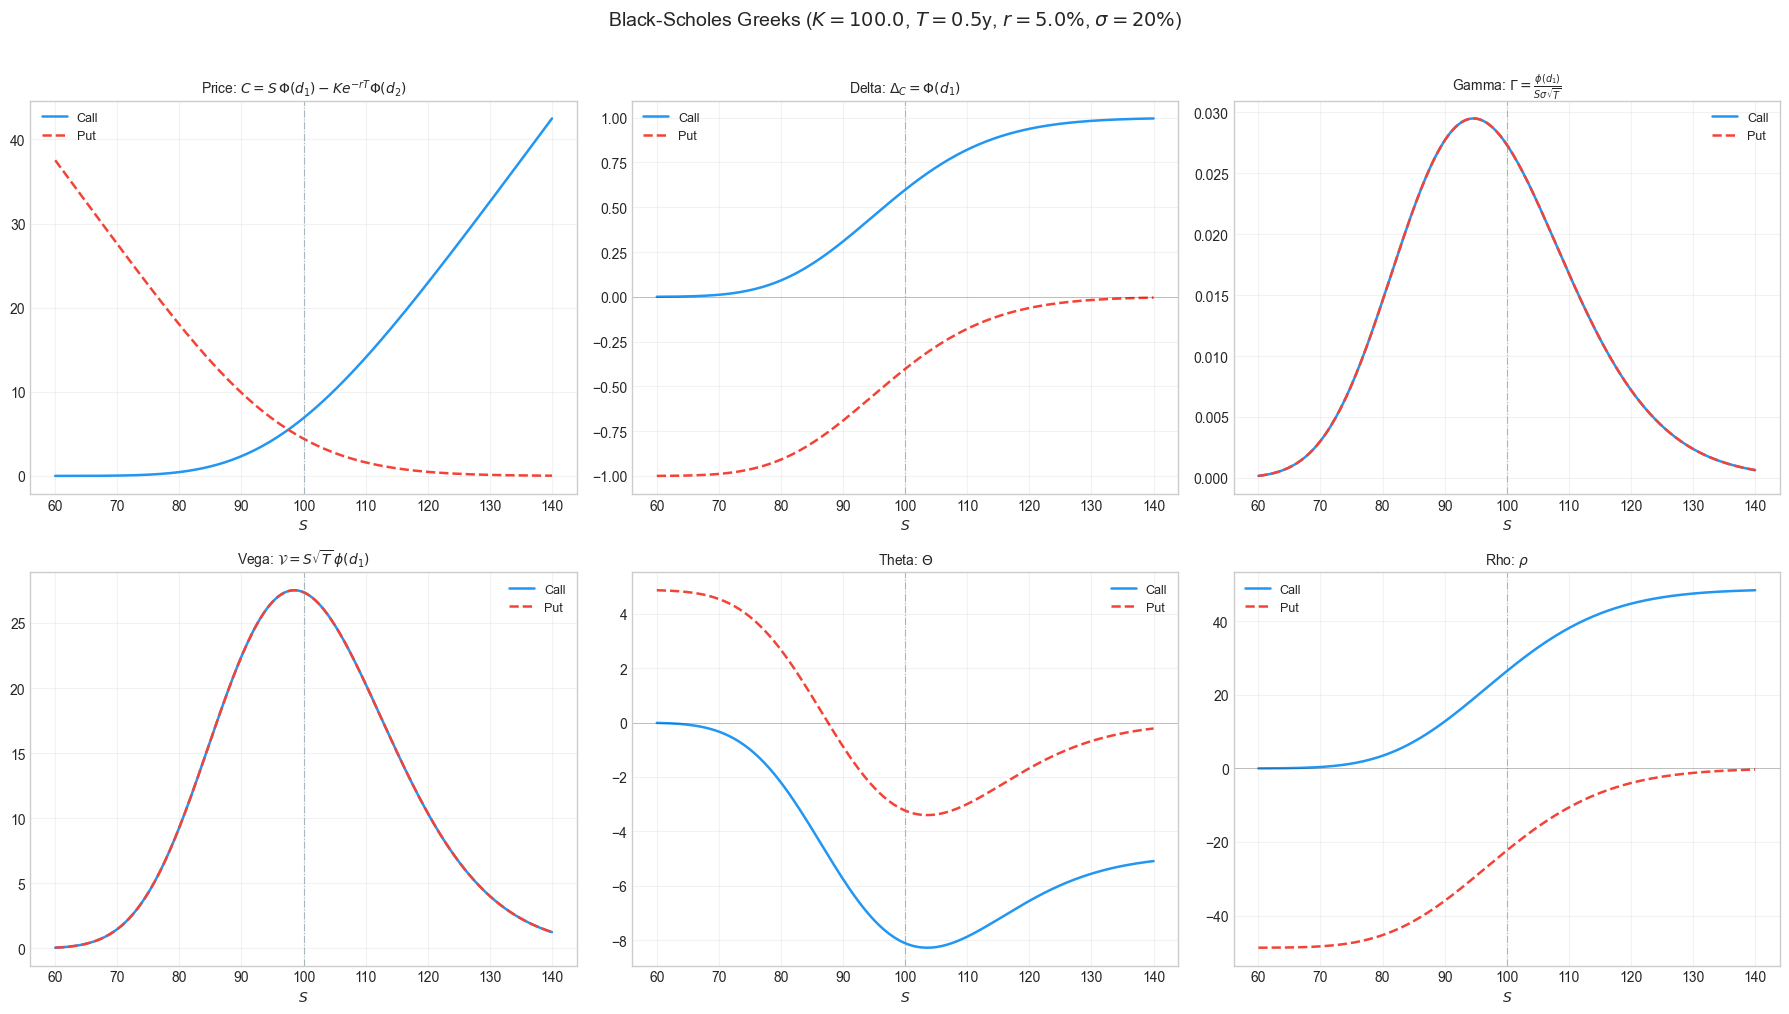

In [5]:
from exotic_option_pricer.utils.visualization import plot_all_greeks

fig, axes = plot_all_greeks(bs, S_range, K=100.0, T=0.5, r=0.05)

Gamma concentrates around the strike as expiry approaches — the classic "pin risk" picture:
a delta-hedged book gets harder to manage exactly where and when it matters most.

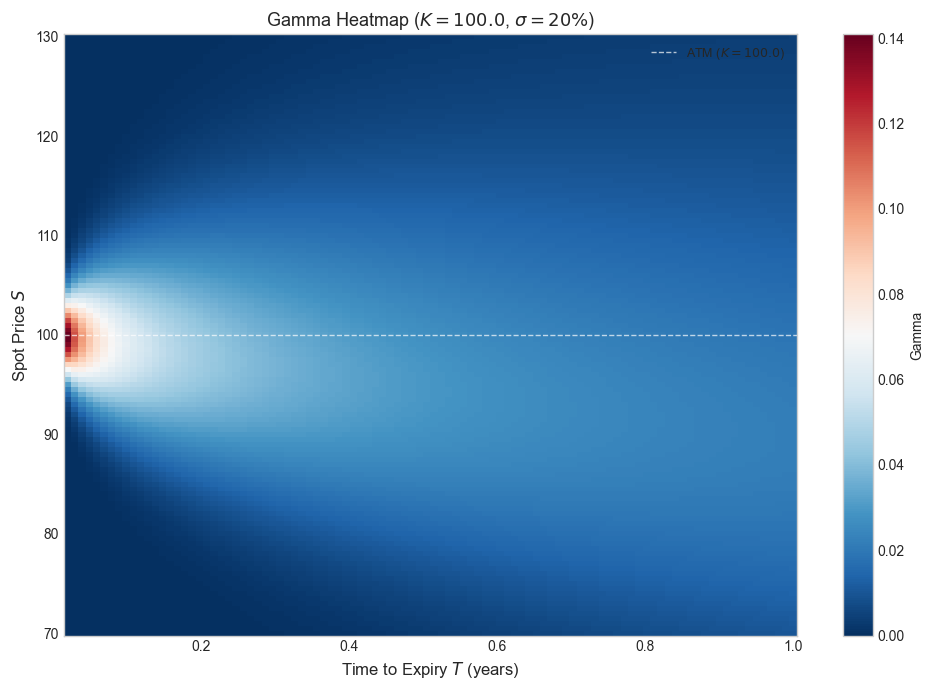

In [6]:
from exotic_option_pricer.utils.visualization import plot_greeks_heatmap

fig, ax = plot_greeks_heatmap(
    bs, 'gamma',
    S_range=np.linspace(70, 130, 121),
    T_range=np.linspace(0.02, 1.0, 100),
    K=100.0, r=0.05,
)

## Implied volatility: Halley's method

The solver inverts the BS formula with cubic convergence (Jaeckel-inspired: regime-dependent
initial guess, Halley iterations on vega/volga, Brent fallback for pathological corners).
Round-trip test: price at a known $\sigma$, invert, recover $\sigma$ — across moneyness,
maturity and vol level simultaneously.

The experiment follows market convention and inverts the **OTM side** (puts below spot,
calls above) — the same convention `iv_surface` uses in this library. The reason: a deep-ITM
price is dominated by intrinsic value; all vol information lives in the extrinsic part, which
underflows exactly like a deep-OTM price. Where the OTM price itself is below double
precision ($\sim 10^{-48}$ at $\sigma = 8\%$, $|k| \approx 0.3$, $T = 0.05$) there is
nothing to invert *for any solver*; those corners are excluded and counted.

In [7]:
vols_true = np.array([0.08, 0.15, 0.25, 0.40, 0.80])
strikes_rt = np.array([70.0, 85.0, 100.0, 115.0, 130.0])
mats = np.array([0.05, 0.25, 1.0, 3.0])

worst = 0.0
n_cases = n_degenerate = 0
t0 = time.perf_counter()
for sigma_true in vols_true:
    model = BlackScholesModel(sigma=float(sigma_true))
    for K_rt in strikes_rt:
        otm_type = 'put' if K_rt < 100.0 else 'call'
        for T_rt in mats:
            price = float(model.price(100.0, float(K_rt), float(T_rt), 0.03, otm_type, q=0.01))
            if price < 1e-8:  # numerically dead: nothing to invert
                n_degenerate += 1
                continue
            iv = BlackScholesModel.implied_vol(
                price, 100.0, float(K_rt), float(T_rt), 0.03, otm_type, q=0.01
            )
            worst = max(worst, abs(iv - sigma_true))
            n_cases += 1
elapsed = time.perf_counter() - t0

print(f"{n_cases} OTM round-trips ({n_degenerate} degenerate corners excluded)")
print(f"max |iv - sigma_true| = {worst:.2e}")
print(f"{1e6 * elapsed / n_cases:.0f} microseconds per price+invert")
assert worst < 1e-9

91 OTM round-trips (9 degenerate corners excluded)
max |iv - sigma_true| = 2.28e-13
83 microseconds per price+invert


---
**Next:** [02 — Monte Carlo engine & variance reduction](02_monte_carlo_variance_reduction.ipynb) ·
[03 — Exotic options](03_exotic_options.ipynb) ·
[04 — Heston](04_heston_stochastic_volatility.ipynb) ·
[05 — Rough Bergomi](05_rough_bergomi_skew.ipynb)